# QSP Demo: Two Perspectives

**Quantum Signal Processing (QSP)** is illustrated from two perspectives:

**Part A**
   QSP via scalar QSVT

**Part B**
   manual QSP-style circuit producing a Chebyshev polynomial

The examples use the polynomial

$$ f(x) = x^3 $$

and the Chebyshev polynomial

$$ T_3(x) = 4x^3 - 3x. $$

## Variable definitions

- $x\in[-1,1]$ is the scalar signal parameter, and $f$ is the monomial target.
- $T_3$ is the degree-three Chebyshev polynomial of the first kind.
- $\theta=\arccos(x)$ is the signal angle.
- $R_y(2\theta)$ is a single-qubit rotation by angle $2\theta$ about the Pauli-$Y$ axis.

## Notebook guide

- **Learning objective:** connect QSP circuit behavior with Chebyshev polynomials.
- **Prerequisites:** an editable repository install plus basic NumPy and linear-algebra familiarity.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](02_QSVT_Singular_Value_Filter.ipynb) · [next](04_QSVT_Exact_Linear_Solver_Toy_Cases.ipynb).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

from qsvt.polynomials import chebyshev_t3, eval_polynomial
from qsvt.qsvt import qsvt_scalar_scan

## Part A
QSP via QSVT on a scalar

When QSVT acts on a scalar $x$, the transformation reduces to applying
a bounded polynomial $f(x)$.

The scalar target is

$$ f(x) = x^3. $$

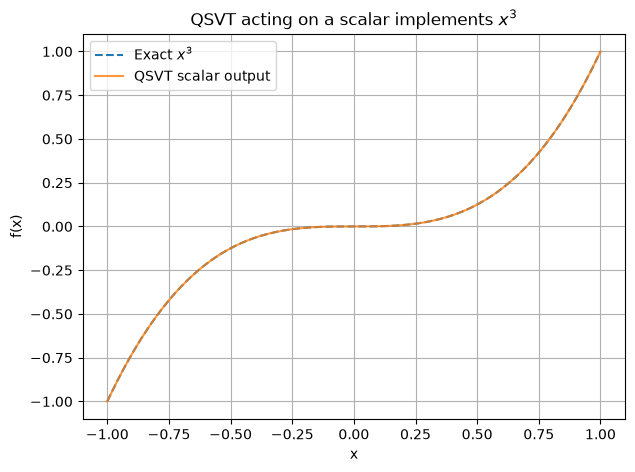

In [2]:
coeffs = np.array([0.0, 0.0, 0.0, 1.0])


x_vals = np.linspace(-1, 1, 200)

qsvt_vals = qsvt_scalar_scan(x_vals, coeffs)
exact_vals = eval_polynomial(coeffs, x_vals)


plt.figure(figsize=(7, 5))
plt.plot(x_vals, exact_vals, "--", label="Exact $x^3$")
plt.plot(x_vals, qsvt_vals, "-", alpha=0.8, label="QSVT scalar output")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("QSVT acting on a scalar implements $x^3$")
plt.grid(True)
plt.legend()
plt.show()

Scalar QSVT reproduces the polynomial $x^3$.

This illustrates the connection:

QSVT acting on a scalar is equivalent to QSP acting on a signal parameter.

## Part B
Manual QSP-style circuit producing a Chebyshev polynomial

A one-qubit circuit implements

$$ T_3(x) = 4x^3 - 3x. $$

Using the identity:

$$
R_y(2\theta)^3
\quad\Rightarrow\quad
\cos(3\theta) = T_3(\cos\theta).
$$

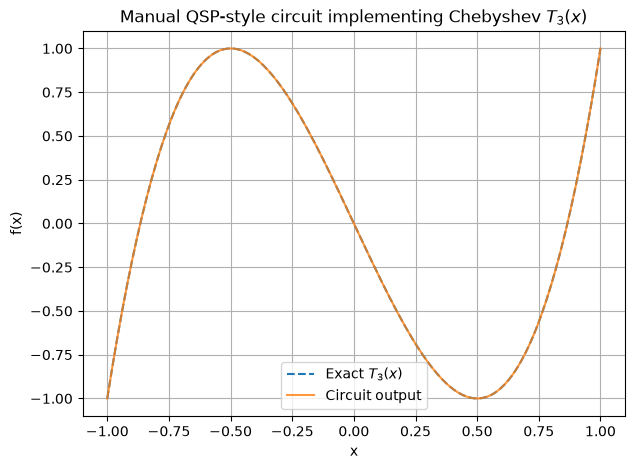

In [3]:
dev = qml.device("default.qubit", wires=1)


@qml.qnode(dev)
def chebyshev_circuit(theta):

    for _ in range(3):
        qml.RY(2 * theta, wires=0)

    return qml.state()


def chebyshev_output(x):

    theta = np.arccos(x)

    state = chebyshev_circuit(theta)

    return np.real(state[0])


x_vals = np.linspace(-1, 1, 200)

circ_vals = np.array([chebyshev_output(x) for x in x_vals])

T3_vals = chebyshev_t3(x_vals)


plt.figure(figsize=(7, 5))

plt.plot(x_vals, T3_vals, "--", label="Exact $T_3(x)$")

plt.plot(x_vals, circ_vals, "-", alpha=0.8, label="Circuit output")

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title("Manual QSP-style circuit implementing Chebyshev $T_3(x)$")

plt.grid(True)
plt.legend()

plt.show()

The circuit output matches the Chebyshev polynomial.

This illustrates the key QSP idea:

repeated application of a signal unitary builds polynomial structure.

## Validation

Compact checks for the expected tutorial behavior.


In [4]:
assert np.allclose(qsvt_vals, exact_vals, atol=1e-9)
assert np.allclose(circ_vals, T3_vals, atol=1e-9)
assert abs(chebyshev_output(0.5) - chebyshev_t3(0.5)) < 1e-9

print(f"qsvt_scan_max_error: {np.max(np.abs(qsvt_vals - exact_vals)):.3e}")
print(f"circuit_max_error: {np.max(np.abs(circ_vals - T3_vals)):.3e}")
print("validation: passed")

qsvt_scan_max_error: 9.999e-13
circuit_max_error: 7.216e-16
validation: passed


## Takeaways and next steps

- **Result:** The workflow shows how to connect QSP circuit behavior with Chebyshev polynomials.
- **Interpretation boundary:** Treat simulator-scale circuits and resource proxies according to the truth contract stated in the notebook.
- **Continue:** [collection index](README.md) · [previous](02_QSVT_Singular_Value_Filter.ipynb) · [next](04_QSVT_Exact_Linear_Solver_Toy_Cases.ipynb).
